In [1]:
# ============================================
# California Coastal Conditions Pipeline
# Stage 4 of 4: Merge, store, and visualize
# Author: Brittany Blessie
# Description: Loads the three cleaned datasets into a SQLite database, joins them by
#              location, filters bad matches, and visualizes California coastal conditions.
# ============================================

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Read the three cleaned datasets produced by the earlier notebooks
calcofi = pd.read_csv("calcofi_clean.csv")
lighthouses = pd.read_csv("lighthouses_clean.csv")
weather = pd.read_csv("weather_clean.csv")

# Confirm each loaded by checking their shapes
print("CalCOFI:", calcofi.shape)
print("Lighthouses:", lighthouses.shape)
print("Weather:", weather.shape)

CalCOFI: (690909, 11)
Lighthouses: (50, 4)
Weather: (50, 6)


## Step 1: Limit CalCOFI to Surface Measurements
Keep only CalCOFI readings from the top 10 meters. Surface ocean conditions are what relate to the surface weather data, so this keeps the merged dataset coherent and a workable size for visualization.

In [4]:
# Step #1: Limit CalCOFI to near-surface measurements (top 10 meters).
calcofi_surface = calcofi[calcofi["Depth_m"] <= 10]
print(calcofi_surface.shape)

(71979, 11)


**Observation:** Filtering to the top 10 meters left 71,979 surface readings out of the original 690,909. This is a workable size for merging and visualization and keeps the ocean data at the surface, where it pairs sensibly with the surface weather.

## Step 2: Match Each CalCOFI Reading to Its Nearest Lighthouse
Calculate the distance from each surface reading to every lighthouse using the haversine formula, then label each reading with its closest lighthouse. This gives the ocean data a shared key it can join on, since it does not share exact coordinates with the other sources.

In [5]:
# Step #2: Match each CalCOFI surface reading to its nearest lighthouse.
import math

# Haversine formula: distance in miles between two lat/lon points on Earth's surface.
def haversine(lat1, lon1, lat2, lon2):
    R = 3959  # Earth's radius in miles
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

# For one location, find the name of the closest lighthouse.
def nearest_lighthouse(lat, lon):
    distances = lighthouses.apply(
        lambda row: haversine(lat, lon, row["Latitude"], row["Longitude"]),
        axis=1
    )
    return lighthouses.loc[distances.idxmin(), "Name"]

# Get the unique coordinate pairs only, so we compute each once instead of 72,000 times.
unique_coords = calcofi_surface[["Latitude", "Longitude"]].drop_duplicates()
unique_coords["Nearest_Lighthouse"] = unique_coords.apply(
    lambda row: nearest_lighthouse(row["Latitude"], row["Longitude"]),
    axis=1
)

# Merge the answers back onto all the surface readings by their coordinates.
calcofi_surface = calcofi_surface.merge(unique_coords, on=["Latitude", "Longitude"], how="left")

print(calcofi_surface.shape)
calcofi_surface[["Latitude", "Longitude", "Nearest_Lighthouse"]].head(10)

(71979, 12)


,Latitude,Longitude,Nearest_Lighthouse
0,40.833333,-124.833333,Table Bluff Light
1,40.833333,-124.833333,Table Bluff Light
2,40.833333,-124.833333,Table Bluff Light
3,40.550000,-126.400000,Cape Mendocino Light
4,40.550000,-126.400000,Cape Mendocino Light
5,40.550000,-126.400000,Cape Mendocino Light
6,40.200000,-127.633333,Cape Mendocino Light
7,40.200000,-127.633333,Cape Mendocino Light
8,39.966666,-129.183333,Cape Mendocino Light
9,39.966666,-129.183333,Cape Mendocino Light


**Observation:** Each surface reading now carries the name of its nearest lighthouse. The matches make geographic sense, with northern readings paired to northern lighthouses like Table Bluff and Cape Mendocino. Computing the match once per unique coordinate pair and mapping it back kept this fast.

In [6]:
calcofi_surface["Nearest_Lighthouse"].value_counts()

Nearest_Lighthouse
Point Loma Light (new)         21403
Point Conception Light         10996
Point Arguello Light            8945
Anacapa Island Light            8313
Point Vicente Light             3373
Point Sur Light                 2492
Ballast Point Light             2463
Long Beach Light                2086
Farallon Island Light           1865
Point San Luis Light            1775
Santa Barbara Light             1464
Point Fermin Light              1343
Point Hueneme Light             1072
Piedras Blancas Light           1013
Point Arena Light                618
St. George Reef Light            569
Pigeon Point Light               452
Point Pinos Light                441
Cape Mendocino Light             334
Point Cabrillo Light             196
Point Reyes Light                192
Santa Cruz Light                 187
Punta Gorda Light                146
Point Loma Light (old)            71
Los Angeles Harbor Light          60
Table Bluff Light                 41
Ano Nuevo Light    

**Observation:** Each surface reading now carries its nearest lighthouse. All 31 matched lighthouses are real coastal California lighthouses, with no inland ones from Lake Tahoe. The heaviest matches fall on Southern California lighthouses like Point Loma and Point Conception, which fits where CalCOFI sampled most. This check only rules out inland errors, and Step 6 measures how far the matches actually stretch.

## Step 3: Load the Three Datasets into a SQLite Database
Open a SQLite database and write each cleaned dataset into it as its own table, so they can be joined with SQL.

In [7]:
# Step #3: Load the three cleaned datasets into SQLite as separate tables.
conn = sqlite3.connect("coastal.db")

calcofi_surface.to_sql("calcofi", conn, if_exists="replace", index=False)
lighthouses.to_sql("lighthouses", conn, if_exists="replace", index=False)
weather.to_sql("weather", conn, if_exists="replace", index=False)

print("Tables written to coastal.db")

Tables written to coastal.db


**Observation:** All three cleaned datasets are now stored as separate tables (calcofi, lighthouses, weather) in the SQLite database coastal.db, ready to be joined with SQL.

## Step 4: Join the Three Tables with SQL
Use a SQL query to join CalCOFI to lighthouses by the nearest lighthouse name, and lighthouses to weather by their shared coordinates, producing one combined dataset. The lighthouse coordinates come along so the distance between each reading and its matched lighthouse can be measured in the next step.

In [8]:
# Step #4: Join the three tables into one dataset with a SQL query.
query = """
SELECT
    c.Cast_ID,
    c.Depth_m,
    c.Temperature_C,
    c.Salinity_PSU,
    c.Oxygen_mL_L,
    c.Latitude AS Cast_Latitude,
    c.Longitude AS Cast_Longitude,
    c.Nearest_Lighthouse,
    l.Location AS Lighthouse_Location,
    l.Latitude AS Lighthouse_Latitude,
    l.Longitude AS Lighthouse_Longitude,
    w.Temperature_F AS Air_Temperature_F,
    w.Humidity,
    w.Wind_Speed,
    w.Description AS Weather_Description
FROM calcofi c
JOIN lighthouses l ON c.Nearest_Lighthouse = l.Name
JOIN weather w ON l.Latitude = w.Latitude AND l.Longitude = w.Longitude
"""

merged = pd.read_sql(query, conn)
print(merged.shape)
merged.head(10)

(71979, 15)


,Cast_ID,Depth_m,Temperature_C,Salinity_PSU,Oxygen_mL_L,Cast_Latitude,Cast_Longitude,Nearest_Lighthouse,Lighthouse_Location,Lighthouse_Latitude,Lighthouse_Longitude,Air_Temperature_F,Humidity,Wind_Speed,Weather_Description
0,71,0,10.30,33.030,5.90,40.833333,-124.833333,Table Bluff Light,Table Bluff,40.695839,-124.273933,64.42,81,5.75,Overcast clouds
1,71,6,18.46,32.920,6.02,40.833333,-124.833333,Table Bluff Light,Table Bluff,40.695839,-124.273933,64.42,81,5.75,Overcast clouds
2,71,10,10.29,32.951,6.04,40.833333,-124.833333,Table Bluff Light,Table Bluff,40.695839,-124.273933,64.42,81,5.75,Overcast clouds
3,72,0,9.80,32.630,6.22,40.550000,-126.400000,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds
4,72,9,9.63,32.740,6.34,40.550000,-126.400000,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds
5,72,10,9.63,32.738,6.34,40.550000,-126.400000,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds
6,73,0,10.09,32.790,5.89,40.200000,-127.633333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds
7,73,10,9.85,32.767,5.22,40.200000,-127.633333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds
8,74,0,9.70,32.750,6.08,39.966666,-129.183333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds
9,74,9,9.78,32.810,6.35,39.966666,-129.183333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds


**Observation:** The SQL join produced one combined dataset of 71,979 rows and 15 columns. Every ocean reading is now linked to its nearest lighthouse and to that lighthouse's current weather, so ocean measurements and surface weather sit side by side for each location. The column aliases keep the ocean and air values clearly separate, with Cast_Latitude and Lighthouse_Latitude naming which position each coordinate belongs to.

## Step 5: Remove Within-Cast Temperature Outliers
Compare each reading to the median temperature of its own cast and drop readings that sit far from the rest. A reading several degrees off from others taken meters away in the same cast is a sensor error, not real stratification. Casts holding only two readings need a separate rule, since a median halfway between two values cannot identify which one is wrong.

In [9]:
# Step #5: Remove readings that disagree with the rest of their own cast.
# Each cast samples the same water column within a few meters, so a reading far from
# the cast median is a sensor error rather than a real temperature change.
cast_median = merged.groupby("Cast_ID")["Temperature_C"].transform("median")
outliers = (merged["Temperature_C"] - cast_median).abs() > 5

# A cast with only two readings has its median halfway between them, so neither value
# can be outvoted. When those two disagree sharply, drop both since there is no way to
# tell which one is the bad sensor.
cast_size = merged.groupby("Cast_ID")["Temperature_C"].transform("size")
cast_spread = merged.groupby("Cast_ID")["Temperature_C"].transform(lambda x: x.max() - x.min())
ambiguous = (cast_size == 2) & (cast_spread > 5)

drop = outliers | ambiguous
print("Rows flagged by cast median:", outliers.sum())
print("Rows flagged in two-reading casts:", ambiguous.sum())
print("Total dropped:", drop.sum())

merged = merged[~drop].reset_index(drop=True)
print("Shape after removal:", merged.shape)

Rows flagged by cast median: 37
Rows flagged in two-reading casts: 42
Total dropped: 79
Shape after removal: (71900, 15)


**Observation:** Two rules flagged 79 readings. The cast median rule caught 37, including the 18.46 C value at 6 meters in cast 71 where the surrounding readings were near 10.3 C. The two-reading rule caught another 42 in casts where only two measurements exist, so the median sits halfway between them and neither value can be outvoted. Cast 79 is one of those, with 10.20 C at the surface and 17.24 C at 10 meters, and there is no way to tell which sensor was wrong, so both go. That left 71,900 rows. Comparing each reading to its own cast means the rule adapts to warm southern water and cold northern water instead of assuming one valid temperature range for the whole coast.

## Step 6: Measure the Distance to Each Matched Lighthouse
Calculate how far each reading actually sits from the lighthouse it was matched to. The nearest lighthouse can still be hundreds of miles away, so this makes the stretch visible before deciding which matches to keep.

In [10]:
# Step #6: Calculate the distance from each reading to its matched lighthouse.
# Vectorized haversine so it runs across all rows at once instead of row by row.
lat1 = np.radians(merged["Cast_Latitude"])
lon1 = np.radians(merged["Cast_Longitude"])
lat2 = np.radians(merged["Lighthouse_Latitude"])
lon2 = np.radians(merged["Lighthouse_Longitude"])

dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
merged["Distance_Miles"] = 3959 * 2 * np.arcsin(np.sqrt(a))

print(merged["Distance_Miles"].describe())
print()
print("Rows over 100 miles:", (merged["Distance_Miles"] > 100).sum())
print("Rows over 200 miles:", (merged["Distance_Miles"] > 200).sum())
print("Rows over 500 miles:", (merged["Distance_Miles"] > 500).sum())

count    71900.000000
mean       182.751484
std        183.793542
min          1.050896
25%         39.724735
50%        131.427219
75%        264.391242
max       2173.407770
Name: Distance_Miles, dtype: float64

Rows over 100 miles: 40740
Rows over 200 miles: 25754
Rows over 500 miles: 4808


**Observation:** Distances run from 1 mile to 2,173 miles, with a median of 131 miles. Half the readings sit within about 131 miles of their matched lighthouse, which is expected since CalCOFI samples open ocean while lighthouses stand on shore. The long tail is the problem, with 4,808 readings more than 500 miles from the lighthouse they were assigned. A reading that far away is not meaningfully near that lighthouse, and the next step removes those.

## Step 7: Drop Matches That Are Too Far to Be Meaningful
Remove readings whose nearest lighthouse is more than 500 miles away. CalCOFI sampled well south of the California border, and those readings were being labeled with California lighthouses, which misrepresents where the data came from.

In [11]:
# Step #7: Drop readings whose matched lighthouse is unreasonably far away.
# CalCOFI sampled south into Mexican waters, and those readings still matched to the
# nearest California lighthouse even when it sat over a thousand miles away.
too_far = merged["Distance_Miles"] > 500

print("Rows dropped:", too_far.sum())
print("Latitude range before:", merged["Cast_Latitude"].min(), "to", merged["Cast_Latitude"].max())

merged = merged[~too_far].reset_index(drop=True)

print("Latitude range after:", merged["Cast_Latitude"].min(), "to", merged["Cast_Latitude"].max())
print("Shape after removal:", merged.shape)

Rows dropped: 4808
Latitude range before: 19.116666 to 47.916666
Latitude range after: 25.433333 to 47.916666
Shape after removal: (67092, 16)


**Observation:** Dropping the 4,808 readings more than 500 miles from their matched lighthouse left 67,092 rows, about 93 percent of what came out of the join. The southern edge moved from latitude 19.1 up to 25.4, which removes the readings off central Mexico that were being labeled with San Diego lighthouses. The northern edge stayed at 47.9, since a reading off Oregon can sit within 500 miles of a northern California lighthouse and still be a fair match. The Distance_Miles column stays in the dataset so anyone using it can filter tighter than I did.

## Step 8: Visualization 1 - Ocean Temperature by Latitude
Plot each surface reading's ocean temperature against its latitude to show how the water cools moving north along the California coast. Uses CalCOFI data.

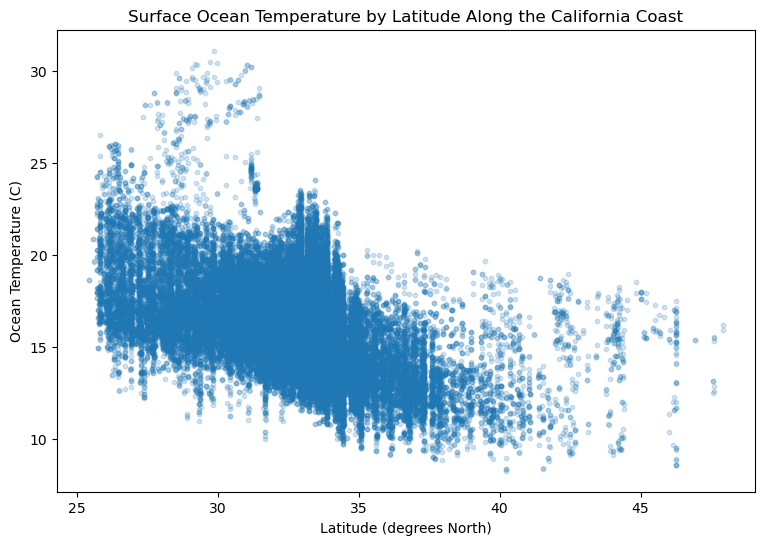

In [12]:
# Step #8: Visualization 1 - Ocean temperature by latitude (CalCOFI).
plt.figure(figsize=(9, 6))
plt.scatter(merged["Cast_Latitude"], merged["Temperature_C"], alpha=0.2, s=10)
plt.xlabel("Latitude (degrees North)")
plt.ylabel("Ocean Temperature (C)")
plt.title("Surface Ocean Temperature by Latitude Along the California Coast")
plt.show()

**Observation:** Ocean temperature drops moving north, from a spread of roughly 15 to 30 C at latitude 25 down to 10 to 15 C past latitude 40. The heaviest concentration of readings sits between latitudes 30 and 35, which is where CalCOFI sampled most. There is a visible narrowing around latitude 34 where the warm upper edge falls away, matching the corner at Point Conception where the coastline turns and colder water dominates. The pattern lines up with the cold California Current flowing south along the coast.

## Step 9: Visualization 2 - Ocean Temperature vs Air Temperature by Location
Compare the average ocean temperature at each lighthouse to the air temperature there, to see whether the water and the air track together. Uses CalCOFI and weather data, spanning two sources.

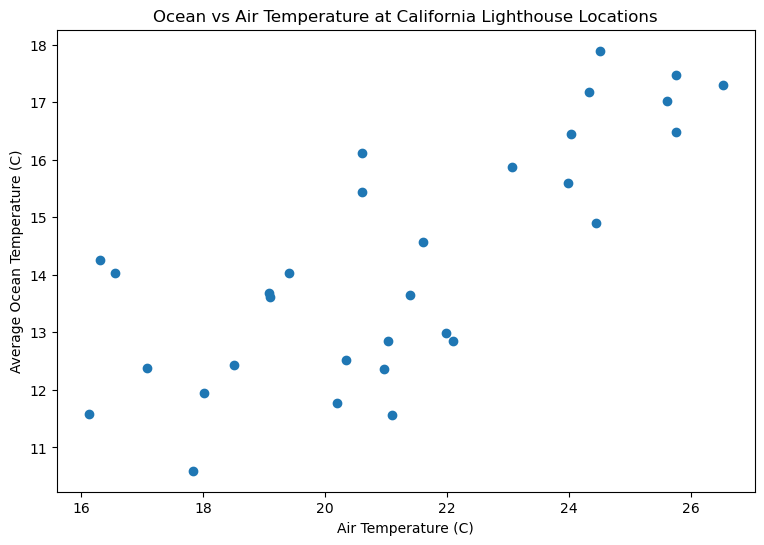

In [13]:
# Step #9: Visualization 2 - Ocean vs air temperature per lighthouse (CalCOFI + weather).
# Average ocean temp per lighthouse, and take that lighthouse's single air temperature.
by_lighthouse = merged.groupby("Nearest_Lighthouse").agg(
    Avg_Ocean_Temp_C=("Temperature_C", "mean"),
    Air_Temp_F=("Air_Temperature_F", "first")
).reset_index()

# Convert air temp from F to C so both are on the same scale.
by_lighthouse["Air_Temp_C"] = (by_lighthouse["Air_Temp_F"] - 32) * 5/9

plt.figure(figsize=(9, 6))
plt.scatter(by_lighthouse["Air_Temp_C"], by_lighthouse["Avg_Ocean_Temp_C"])
plt.xlabel("Air Temperature (C)")
plt.ylabel("Average Ocean Temperature (C)")
plt.title("Ocean vs Air Temperature at California Lighthouse Locations")
plt.show()

**Observation:** There is a loose positive relationship between air and ocean temperature across locations. Lighthouses with warmer air tend to have warmer average ocean temperatures, but the spread is wide, which makes sense because ocean temperature is driven by currents and location more than by the current air temperature. This chart combines the CalCOFI and weather sources.

## Step 10: Visualization 3 - Average Ocean Temperature by Lighthouse
Show the average ocean temperature at each lighthouse location as a bar chart, ordered from coldest to warmest. Uses CalCOFI and lighthouse data, spanning two sources.

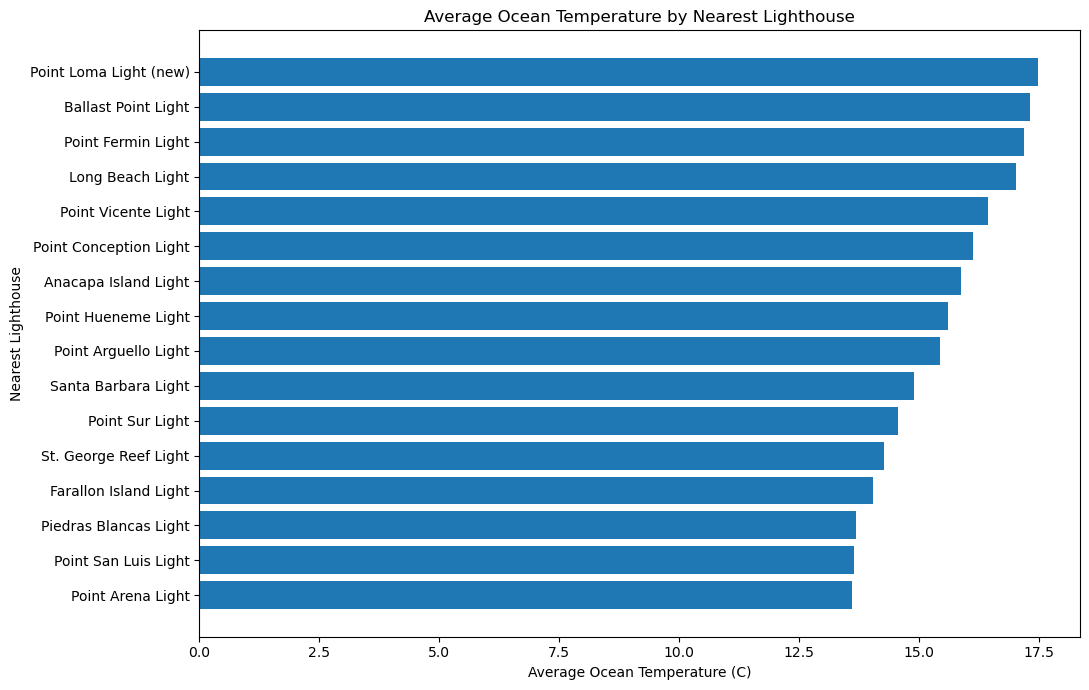

In [14]:
# Step #10: Visualization 3 - Average ocean temperature per lighthouse (CalCOFI + lighthouses).
# Average ocean temp per lighthouse, sorted, and limited to lighthouses with enough readings.
lighthouse_temps = merged.groupby("Nearest_Lighthouse").agg(
    Avg_Ocean_Temp_C=("Temperature_C", "mean"),
    Reading_Count=("Temperature_C", "count")
).reset_index()

# Keep only lighthouses with a solid number of readings so averages are meaningful.
lighthouse_temps = lighthouse_temps[lighthouse_temps["Reading_Count"] >= 500]
lighthouse_temps = lighthouse_temps.sort_values("Avg_Ocean_Temp_C")

plt.figure(figsize=(11, 7))
plt.barh(lighthouse_temps["Nearest_Lighthouse"], lighthouse_temps["Avg_Ocean_Temp_C"])
plt.xlabel("Average Ocean Temperature (C)")
plt.ylabel("Nearest Lighthouse")
plt.title("Average Ocean Temperature by Nearest Lighthouse")
plt.tight_layout()
plt.show()

**Observation:** Average ocean temperature is highest at Southern California lighthouses like Point Loma, Ballast Point, and Long Beach, and lowest at central and northern lighthouses like Point San Luis and Point Arena. This shows the same north-south cooling gradient as the latitude chart, but tied to named coastal locations, and it combines the CalCOFI and lighthouse sources.

## Step 11: Visualization 4 - Ocean Temperature vs Dissolved Oxygen
Plot ocean temperature against dissolved oxygen to show their physical relationship, since colder water holds more oxygen. Uses CalCOFI data.

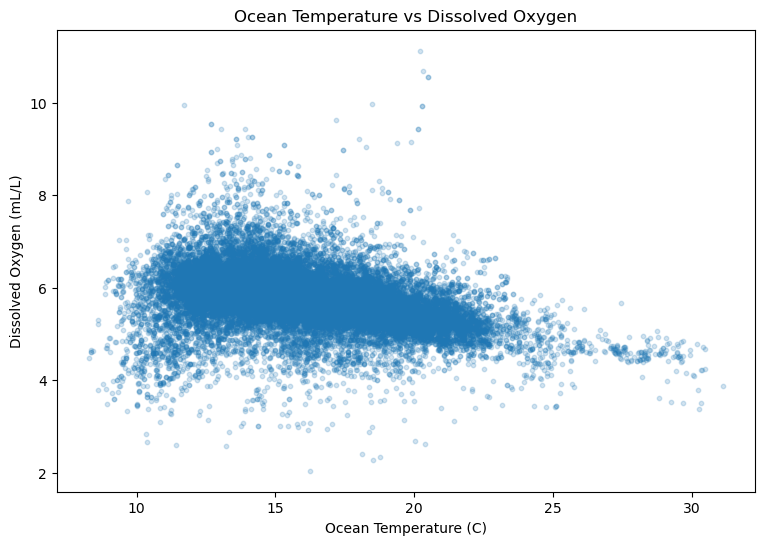

In [15]:
# Step #11: Visualization 4 - Ocean temperature vs dissolved oxygen (CalCOFI).
plt.figure(figsize=(9, 6))
plt.scatter(merged["Temperature_C"], merged["Oxygen_mL_L"], alpha=0.2, s=10)
plt.xlabel("Ocean Temperature (C)")
plt.ylabel("Dissolved Oxygen (mL/L)")
plt.title("Ocean Temperature vs Dissolved Oxygen")
plt.show()

**Observation:** Dissolved oxygen tends to be higher and more variable in colder water and settles lower, around 4 to 5 mL/L, as temperature rises. This matches the known physical rule that warmer water holds less dissolved oxygen, and it shows the ocean measurements behave the way real ocean chemistry should.

## Step 12: Visualization 5 - Distribution of Surface Salinity
Show how surface salinity is distributed across all readings with a histogram. Uses CalCOFI data.

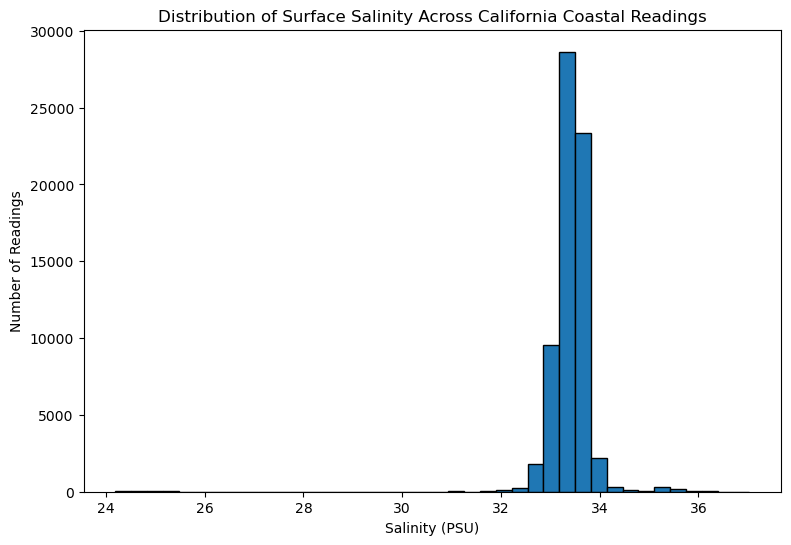

In [16]:
# Step #12: Visualization 5 - Distribution of surface salinity (CalCOFI).
plt.figure(figsize=(9, 6))
plt.hist(merged["Salinity_PSU"], bins=40, edgecolor="black")
plt.xlabel("Salinity (PSU)")
plt.ylabel("Number of Readings")
plt.title("Distribution of Surface Salinity Across California Coastal Readings")
plt.show()

**Observation:** Surface salinity clusters hard between 33 and 34 PSU, with the tallest bar just under 33.5 holding roughly 28,000 readings. A thin tail runs down toward 24 PSU and a smaller one up past 35. The tight center is what open ocean water should look like, and the low outliers are probably readings taken near river mouths or after heavy runoff, where fresh water dilutes the surface layer.

## Step 13: Print the Final Merged Dataset
Display the first rows of the finished dataset and its shape, showing the fields from all three sources sitting together in one table.

In [17]:
# Step #13: Display the final merged dataset.
print("Final merged dataset shape:", merged.shape)
merged.head(20)

Final merged dataset shape: (67092, 16)


,Cast_ID,Depth_m,Temperature_C,Salinity_PSU,Oxygen_mL_L,Cast_Latitude,Cast_Longitude,Nearest_Lighthouse,Lighthouse_Location,Lighthouse_Latitude,Lighthouse_Longitude,Air_Temperature_F,Humidity,Wind_Speed,Weather_Description,Distance_Miles
0,71,0,10.30,33.030,5.90,40.833333,-124.833333,Table Bluff Light,Table Bluff,40.695839,-124.273933,64.42,81,5.75,Overcast clouds,30.778752
1,71,10,10.29,32.951,6.04,40.833333,-124.833333,Table Bluff Light,Table Bluff,40.695839,-124.273933,64.42,81,5.75,Overcast clouds,30.778752
2,72,0,9.80,32.630,6.22,40.550000,-126.400000,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,105.048978
3,72,9,9.63,32.740,6.34,40.550000,-126.400000,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,105.048978
4,72,10,9.63,32.738,6.34,40.550000,-126.400000,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,105.048978
5,73,0,10.09,32.790,5.89,40.200000,-127.633333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,170.820319
6,73,10,9.85,32.767,5.22,40.200000,-127.633333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,170.820319
7,74,0,9.70,32.750,6.08,39.966666,-129.183333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,254.196215
8,74,9,9.78,32.810,6.35,39.966666,-129.183333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,254.196215
9,74,10,9.78,32.808,6.35,39.966666,-129.183333,Cape Mendocino Light,Shelter Cove,40.439906,-124.406031,61.79,81,13.71,Overcast clouds,254.196215


**Observation:** The finished dataset holds 67,092 rows and 16 columns. Each row is one CalCOFI surface reading with its ocean measurements, the name and location of the nearest lighthouse, the distance to that lighthouse in miles, and the weather recorded there. All three sources are readable in a single row. The first rows are northern casts near latitude 40, with temperatures around 10 C and salinity near 32.8, which fits the cold northern coast. The bad readings visible in earlier versions of this table are gone, since Step 5 removed them before any chart was drawn.

## Summary

I started with three sources that shared nothing except the California coast. CalCOFI came in as a large CSV of ocean measurements. The lighthouse table came from scraping Wikipedia, and the weather came from the OpenWeatherMap API. The hardest part was never the cleaning. It was figuring out that the sources did not share a key at all, since CalCOFI records ship positions out at sea and lighthouses sit at fixed points on land. Building the haversine calculation to label each ocean reading with its nearest lighthouse is what made the join possible, and that step taught me more than anything else in the course. A shared key is something you often have to construct, not something you find waiting in the data. Constructing it is also where the errors hide. My first check was watching for Lake Tahoe lighthouses in the value counts, and seeing none of them made me think the match was fine. It was not. Once I measured the actual distance from each reading to its assigned lighthouse, the maximum came back at 2,173 miles. CalCOFI sampled far down the Baja coast, and those readings were quietly getting labeled with San Diego lighthouses. The Lake Tahoe check was looking for inland errors and never would have caught a match stretching south. Dropping matches beyond 500 miles cost me about 7 percent of the rows and pulled the southern edge from latitude 19 up to 25. Printing the merged table caught a different problem the charts had smoothed over. One cast showed 18.46 C at 6 meters between two readings near 10.3 C, which is a sensor error rather than real stratification. Comparing each reading to the median of its own cast flagged 37 of those. That rule missed a second kind, though, because a cast with only two readings puts the median halfway between them and neither value can be outvoted, so cast 79 kept a 10.20 and a 17.24 side by side. Adding a rule for two-reading casts caught 42 more. Loading everything into SQLite changed how I think about size, since filtering CalCOFI to the top ten meters cut 690,909 rows to 71,979 and doing the join in SQL kept the whole thing readable in about fifteen lines. The final dataset came out at 67,092 rows. The air versus ocean temperature chart surprised me. I expected them to track closely and they barely did, which makes sense once you remember that the California Current sets water temperature and a single API call captures one moment of air temperature. That mismatch is the real limitation here, and it is the first thing I would fix if I extended this. Working with some site data from Monterey Bay had already shown me how much time preparation takes, but this project put a number on it.

## Data Notes and Limitations

### What the pipeline changed

Each source was cleaned in its own notebook. CalCOFI had columns renamed to readable names, rows with missing temperature or salinity dropped, and depth values converted to a single numeric column. The lighthouse table scraped from Wikipedia had footnote markers stripped, coordinates parsed out of text into numeric latitude and longitude, and inland lighthouses on Lake Tahoe left in the cleaned file but checked for in the join. The weather data pulled from the API had its nested JSON flattened and temperature kept in Fahrenheit. In this notebook I filtered CalCOFI to the top ten meters and added a Nearest_Lighthouse column that does not exist in any source. Three more changes happened after the join. Readings that disagreed with the median of their own cast were removed, 79 in total, along with a separate rule for two-reading casts where the median cannot identify which value is wrong. A Distance_Miles column was calculated from each reading's position to its matched lighthouse. Readings more than 500 miles from that lighthouse were dropped, 4,808 of them, which cut the dataset from 71,979 rows to 67,092.

### Licensing and attribution

CalCOFI data is published by a partnership between NOAA, Scripps, and California Department of Fish and Wildlife and is free to use, though the program asks that it be credited. Wikipedia content falls under CC BY-SA, which requires attribution and applies the same license to anything derived from it. OpenWeatherMap's free tier limits call volume and does not allow redistributing bulk data. None of the three contain personal information, so privacy law does not apply here, but the attribution terms do and I have cited each source.

### Risks in the transformed data

The nearest-lighthouse column is the largest risk. It is a label I invented, and a reader could easily take it to mean the reading was collected at that lighthouse when the median reading sits 131 miles away. Measuring the distance is what exposed how far the label was stretching, with the worst match sitting 2,173 miles from its assigned lighthouse. The surface filter is a second risk, since anyone using this dataset to describe California ocean temperature would be describing only the top ten meters. Removing readings also carries risk in the other direction. I dropped 79 for disagreeing with their own cast and 4,808 for being too far from a lighthouse, and every removal is a judgment about what counts as wrong. The 500 mile cutoff in particular is a number I chose, not one the data handed me.

### Assumptions

I assumed the top ten meters counts as surface water and pairs sensibly with air temperature. I assumed straight-line haversine distance is a fair way to match an ocean position to a lighthouse, which ignores that a lighthouse across a bay may be closer by distance than by water. I assumed one weather call per lighthouse represents that location, which is the weakest assumption in the project, since it compares a single moment of weather to decades of ocean sampling. The outlier rule assumes a cast samples one water column, so readings within it should agree, and the 500 mile cutoff assumes a match past that distance says nothing useful about location.

### Sourcing and verification

CalCOFI comes from a long-running government and university survey program with published methods. The lighthouse table came from Wikipedia, which is the least authoritative of the three, so I spot-checked coordinates against known locations and watched for inland matches in the value counts. That check only rules out one kind of error. Measuring the actual distance to each matched lighthouse is what caught the real problem, a maximum of 2,173 miles where readings off Baja were being assigned to San Diego lighthouses. Weather came directly from the OpenWeatherMap API rather than a secondhand copy. Beyond the sources themselves, I checked the merged data against physical expectations, and seeing ocean temperature fall with latitude and oxygen fall as water warms gave me some confidence the pipeline had not corrupted anything.

### How the data was acquired

CalCOFI is published for public use. The Wikipedia scrape pulled a single table with one request and no repeated hits on the site. The API calls stayed inside the free tier limits and used my own key, which is read from a local file that is excluded from version control so it never reaches GitHub.

### What still needs documenting

Some of these are handled in the notebook. The Distance_Miles column stays in the final dataset, so anyone can see how far each match stretches and filter tighter than my 500 mile cutoff. Both removal steps print how many rows they dropped and why, so the survivorship is visible rather than silent. What remains is documentation traveling with the data. Anyone using this needs to know that Nearest_Lighthouse is a computed label rather than a collection site, that the rows cover only the top ten meters, and that the weather column is one snapshot instead of a matched historical observation. Pulling historical weather keyed to each cast date would fix the timing mismatch and is the change I would make first. The attribution terms are handled by citing all three sources in the project README and keeping the CC BY-SA notice with anything derived from the Wikipedia table.

In [18]:
# Close the database connection now that all queries are finished.
conn.close()